In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold,cross_val_score

from sklearn.metrics import classification_report,confusion_matrix,roc_curve, auc, roc_auc_score,precision_recall_curve, average_precision_score

from sklearn.ensemble import StackingClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [95]:
file_path = r'C:/Users/test123/Downloads/Midterm Recruit.csv'
cols = ["Age", "Gender", "Education Level", "Experience Years", "Previous Companies", "Distance From Company", "Interview Score", "Skill Score", "Personality Score", "Recruitment Strategy", "Hiring Decision"]

df = pd.read_csv(file_path, names=cols) 
missing_data = df.isnull().sum()
print(missing_data)

Age                      0
Gender                   0
Education Level          0
Experience Years         0
Previous Companies       0
Distance From Company    0
Interview Score          0
Skill Score              0
Personality Score        0
Recruitment Strategy     0
Hiring Decision          0
dtype: int64


In [96]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(df)):
    train= df.iloc[train_index]
    test = df.iloc[test_index]
    
    train_counts = train['Hiring Decision'].value_counts()
    hired_train = train_counts.get(1, 0)  # Number of '1' in train
    not_hired_train = train_counts.get(0, 0)  # Number of '0' in train
    
    print(f"Fold {fold+1}:")
    print(f"Training data: {train.shape}, Hired (1): {hired_train}, Not Hired (0): {not_hired_train}")
    print(f"Test data: {test.shape}")


Fold 1:
Training data: (1350, 11), Hired (1): 427, Not Hired (0): 923
Test data: (150, 11)
Fold 2:
Training data: (1350, 11), Hired (1): 418, Not Hired (0): 932
Test data: (150, 11)
Fold 3:
Training data: (1350, 11), Hired (1): 421, Not Hired (0): 929
Test data: (150, 11)
Fold 4:
Training data: (1350, 11), Hired (1): 416, Not Hired (0): 934
Test data: (150, 11)
Fold 5:
Training data: (1350, 11), Hired (1): 415, Not Hired (0): 935
Test data: (150, 11)
Fold 6:
Training data: (1350, 11), Hired (1): 425, Not Hired (0): 925
Test data: (150, 11)
Fold 7:
Training data: (1350, 11), Hired (1): 423, Not Hired (0): 927
Test data: (150, 11)
Fold 8:
Training data: (1350, 11), Hired (1): 416, Not Hired (0): 934
Test data: (150, 11)
Fold 9:
Training data: (1350, 11), Hired (1): 415, Not Hired (0): 935
Test data: (150, 11)
Fold 10:
Training data: (1350, 11), Hired (1): 409, Not Hired (0): 941
Test data: (150, 11)


In [97]:
def scale(dataframe, oversample=False):
    x=dataframe[dataframe.columns[:-1]].values
    y=dataframe[dataframe.columns[-1]].values
    
    scaler= StandardScaler()
    x= scaler.fit_transform(x)
    
    if oversample:
        smote = SMOTE(random_state=42)
        x, y = smote.fit_resample(x, y)
        
    data = np.hstack((x,np.reshape(y,(-1,1))))
    
    return data,x,y

In [98]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]
    
    train_data, x_train, y_train = scale(train, oversample=True)
    test_data, x_test, y_test = scale(test, oversample=False)
    
    print(f"Fold {fold + 1}:")
    print(f"Training data: {train.shape}, Hired (1): {np.sum(y_train == 1)}, Not Hired (0): {np.sum(y_train == 0)}")
    print(f"Test data: {test.shape}, Hired (1): {np.sum(y_test == 1)}, Not Hired (0): {np.sum(y_test == 0)}")
    print("------------------------------------------------------")

Fold 1:
Training data: (1350, 11), Hired (1): 923, Not Hired (0): 923
Test data: (150, 11), Hired (1): 38, Not Hired (0): 112
------------------------------------------------------
Fold 2:
Training data: (1350, 11), Hired (1): 932, Not Hired (0): 932
Test data: (150, 11), Hired (1): 47, Not Hired (0): 103
------------------------------------------------------
Fold 3:
Training data: (1350, 11), Hired (1): 929, Not Hired (0): 929
Test data: (150, 11), Hired (1): 44, Not Hired (0): 106
------------------------------------------------------
Fold 4:
Training data: (1350, 11), Hired (1): 934, Not Hired (0): 934
Test data: (150, 11), Hired (1): 49, Not Hired (0): 101
------------------------------------------------------
Fold 5:
Training data: (1350, 11), Hired (1): 935, Not Hired (0): 935
Test data: (150, 11), Hired (1): 50, Not Hired (0): 100
------------------------------------------------------
Fold 6:
Training data: (1350, 11), Hired (1): 925, Not Hired (0): 925
Test data: (150, 11), Hir

In [99]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]
    
    scaler = StandardScaler()
    x_train = scaler.fit_transform(train[train.columns[:-1]].values)
    y_train = train['Hiring Decision'].values
    
    smote = SMOTE(random_state=42)
    x_train, y_train = smote.fit_resample(x_train, y_train)
    
    x_test = scaler.transform(test[test.columns[:-1]].values)
    y_test = test['Hiring Decision'].values
    
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(x_train, y_train)
    
    y_pred_rf = rf_model.predict(x_test)
    
    print(f"Fold {fold + 1}:")
    print("Classification Report:\n", classification_report(y_test, y_pred_rf))
    print("------------------------------------------------------")

Fold 1:
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       112
           1       0.87      0.87      0.87        38

    accuracy                           0.93       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.93      0.93      0.93       150

------------------------------------------------------
Fold 2:
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94       103
           1       0.87      0.87      0.87        47

    accuracy                           0.92       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.92      0.92      0.92       150

------------------------------------------------------
Fold 3:
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.92       106
           1       0.84      0.

# Average CLassification report

In [100]:
def average_report(reports):
    avg_report = {}
    
    for key in reports[0].keys():
        if isinstance(reports[0][key], dict):
            avg_report[key] = {metric: np.mean([report[key][metric] for report in reports])
                               for metric in reports[0][key]}
        else:
            avg_report[key] = np.mean([report[key] for report in reports])
    
    return avg_report


In [101]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

classifiers = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(algorithm="SAMME",random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}


    
fold_f1_scores = {clf_name: [] for clf_name in classifiers.keys()}
roc_auc_scores = {clf_name: [] for clf_name in classifiers.keys()}
confusion_matrices = {clf_name: [] for clf_name in classifiers.keys()}


for clf_name, clf in classifiers.items():
    print(f"Evaluating {clf_name}...")
    
    all_classification_reports = []
    precision_recall_data = []


    for fold, (train_index, test_index) in enumerate(kf.split(df)):
        train = df.iloc[train_index]
        test = df.iloc[test_index]
        
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train[train.columns[:-1]].values)
        y_train = train['Hiring Decision'].values
        
        smote = SMOTE(random_state=42)
        x_train, y_train = smote.fit_resample(x_train, y_train)
        
        x_test = scaler.transform(test[test.columns[:-1]].values)
        y_test = test['Hiring Decision'].values
        
        clf.fit(x_train, y_train)
        
        y_pred = clf.predict(x_test)
        
        report = classification_report(y_test, y_pred, output_dict=True)
        all_classification_reports.append(report)
        
        if hasattr(clf, "predict_proba"):
            y_proba = clf.predict_proba(x_test)[:, 1]  # Use probability scores
        else:
            y_proba = clf.decision_function(x_test)
        
        roc_auc = roc_auc_score(y_test, y_proba)
        roc_auc_scores[clf_name].append(roc_auc)
        f1_score_fold = report['weighted avg']['f1-score']
        fold_f1_scores[clf_name].append(f1_score_fold)
        cm = confusion_matrix(y_test, y_pred)
        confusion_matrices[clf_name].append(cm)
        
    avg_report = average_report(all_classification_reports)

    
    print(f"Average Classification Report for {clf_name}:\n")
    print(pd.DataFrame(avg_report).transpose())  # Use Pandas for a nicer output format
    
    avg_roc_auc = np.mean(roc_auc_scores[clf_name])
    print(f"Average ROC AUC for {clf_name}: {avg_roc_auc:.3f}")
    avg_confusion_matrix = np.mean(confusion_matrices[clf_name], axis=0)
    print(f"Average Confusion Matrix for {clf_name}:\n{avg_confusion_matrix}")


    print("\n======================================================\n")



Evaluating KNN...
Average Classification Report for KNN:

              precision    recall  f1-score     support
0              0.894284  0.820397  0.855464  103.500000
1              0.661432  0.785706  0.716995   46.500000
accuracy       0.809333  0.809333  0.809333    0.809333
macro avg      0.777858  0.803051  0.786229  150.000000
weighted avg   0.824078  0.809333  0.813494  150.000000
Average ROC AUC for KNN: 0.861
Average Confusion Matrix for KNN:
[[84.9 18.6]
 [10.  36.5]]


Evaluating Naive Bayes...
Average Classification Report for Naive Bayes:

              precision    recall  f1-score     support
0              0.914434  0.817398  0.862786  103.500000
1              0.670948  0.834637  0.742063   46.500000
accuracy       0.821333  0.821333  0.821333    0.821333
macro avg      0.792691  0.826018  0.802424  150.000000
weighted avg   0.840929  0.821333  0.825865  150.000000
Average ROC AUC for Naive Bayes: 0.890
Average Confusion Matrix for Naive Bayes:
[[84.6 18.9]
 [ 7.9 3

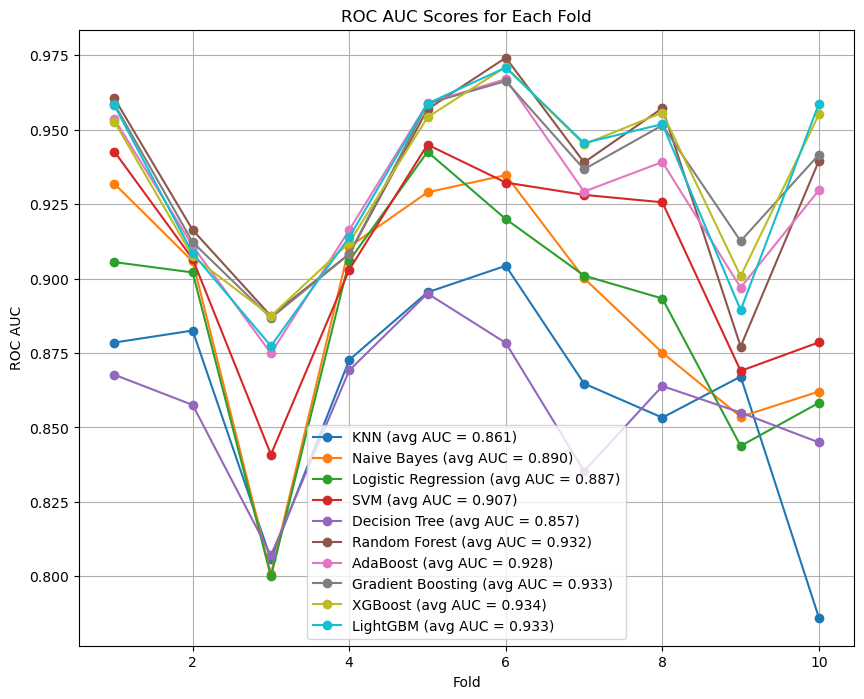

In [102]:
plt.figure(figsize=(10, 8))
for clf_name, auc_scores in roc_auc_scores.items():
    plt.plot(np.arange(1, len(auc_scores) + 1), auc_scores, marker='o', linestyle='-', label=f'{clf_name} (avg AUC = {np.mean(auc_scores):.3f})')

plt.title('ROC AUC Scores for Each Fold')
plt.xlabel('Fold')
plt.ylabel('ROC AUC')
plt.legend()
plt.grid(True)
plt.show()

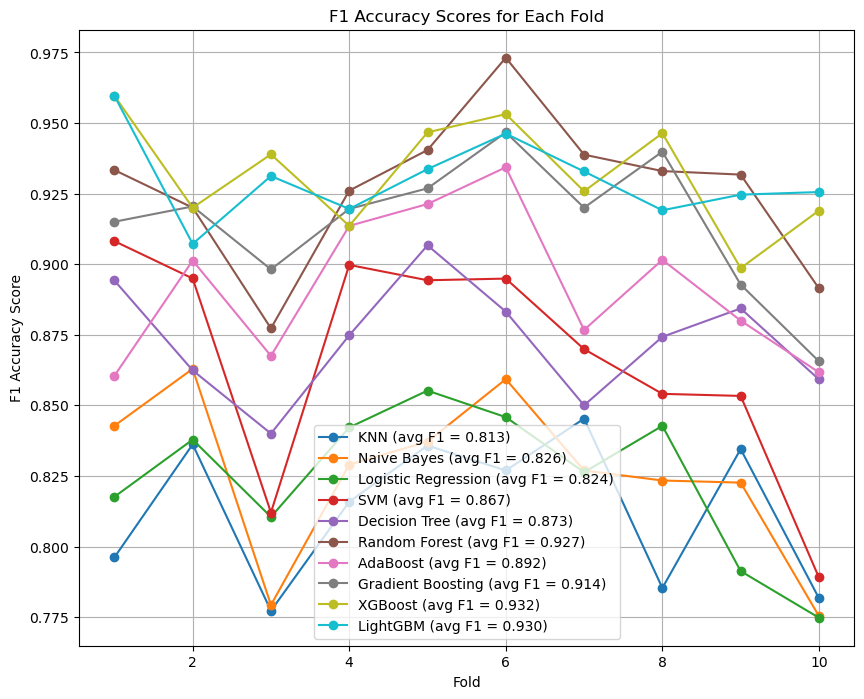

In [103]:
plt.figure(figsize=(10, 8))

# Plot F1 accuracy scores across folds for each model
for clf_name, f1_scores in fold_f1_scores.items():
    plt.plot(
        np.arange(1, len(f1_scores) + 1),
        f1_scores,
        marker='o',
        linestyle='-',
        label=f'{clf_name} (avg F1 = {np.mean(f1_scores):.3f})'
    )

# Add labels and title
plt.title('F1 Accuracy Scores for Each Fold')
plt.xlabel('Fold')
plt.ylabel('F1 Accuracy Score')
plt.legend()
plt.grid(True)
plt.show()

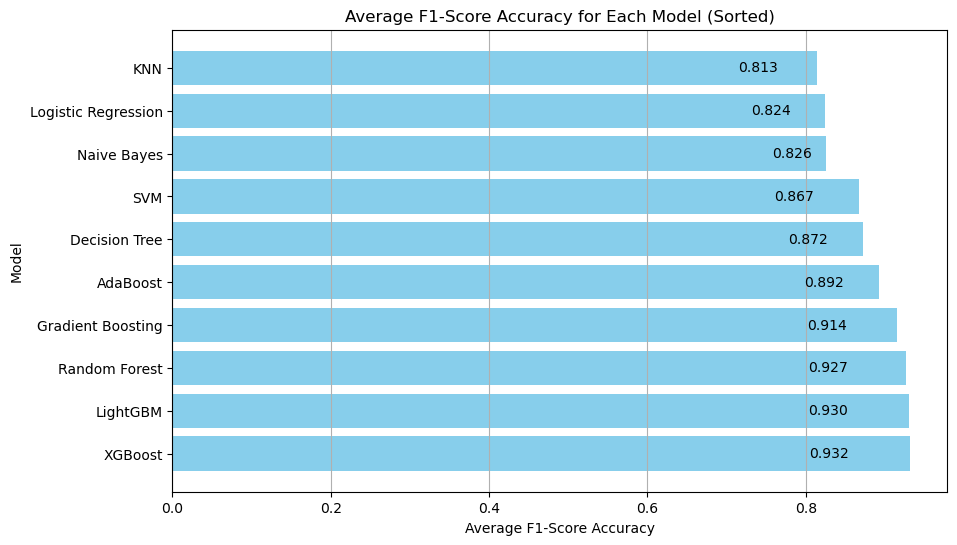

In [104]:

sorted_f1_scores = dict(sorted(average_f1_scores.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(10, 6))
plt.barh(list(sorted_f1_scores.keys()), list(sorted_f1_scores.values()), color='skyblue')
plt.title("Average F1-Score Accuracy for Each Model (Sorted)")
plt.xlabel("Average F1-Score Accuracy")
plt.ylabel("Model")
plt.grid(True, axis='x')
for bar, score in zip(bars, sorted_f1_scores.values()):
    plt.text(bar.get_width() - 0.13, bar.get_y() + bar.get_height() / 2, f'{score:.3f}', va='center')
plt.show()


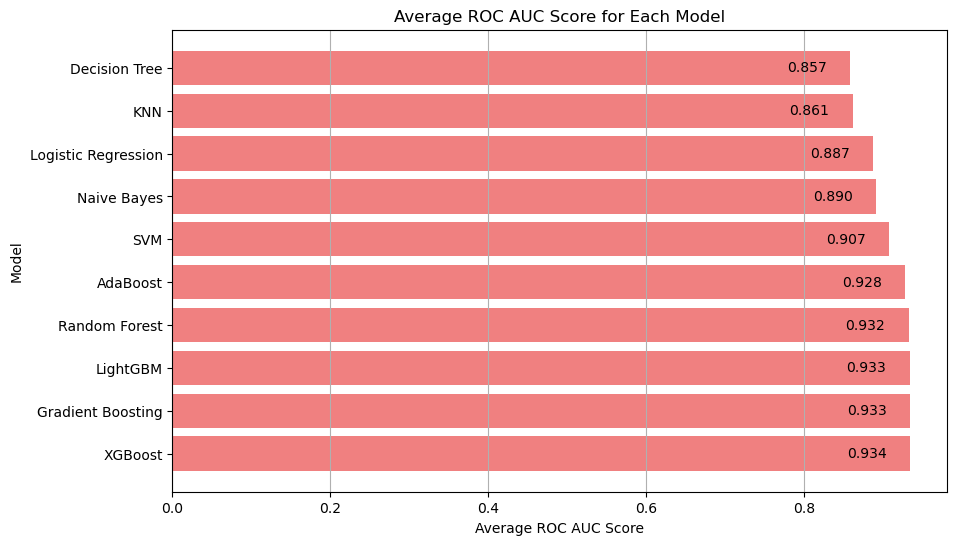

In [105]:

average_auc_scores = {clf_name: np.mean(scores) for clf_name, scores in roc_auc_scores.items()}

sorted_auc_scores = dict(sorted(average_auc_scores.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(10, 6))
bars = plt.barh(list(sorted_auc_scores.keys()), list(sorted_auc_scores.values()), color='lightcoral')
plt.title("Average ROC AUC Score for Each Model")
plt.xlabel("Average ROC AUC Score")
plt.ylabel("Model")
plt.grid(True, axis='x')

for bar, score in zip(bars, sorted_auc_scores.values()):
    plt.text(bar.get_width() - 0.08, bar.get_y() + bar.get_height() / 2, f'{score:.3f}', va='center')

plt.show()


In [106]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

base_models = [
    ('xgboost', XGBClassifier(eval_metric='logloss', random_state=42)),
    ('lightgbm', LGBMClassifier(random_state=42)),
    ('gradient_boosting', GradientBoostingClassifier(random_state=42))
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=kf)

stacking_f1_scores = []
stacking_roc_auc_scores = []

for fold, (train_index, test_index) in enumerate(kf.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]
    
    scaler = StandardScaler()
    x_train = scaler.fit_transform(train[train.columns[:-1]].values)
    y_train = train['Hiring Decision'].values
    
    smote = SMOTE(random_state=42)
    x_train, y_train = smote.fit_resample(x_train, y_train)
    
    x_test = scaler.transform(test[test.columns[:-1]].values)
    y_test = test['Hiring Decision'].values
    stacking_clf.fit(x_train, y_train)

    y_pred = stacking_clf.predict(x_test)
    y_pred_proba = stacking_clf.predict_proba(x_test)[:, 1] if hasattr(stacking_clf, "predict_proba") else stacking_clf.decision_function(x_test)
    
    f1_score_fold = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    stacking_f1_scores.append(f1_score_fold)
    stacking_roc_auc_scores.append(roc_auc)
    
    print(f"Fold {fold + 1} - F1 Score: {f1_score_fold:.3f}, ROC AUC: {roc_auc:.3f}")

avg_stacking_f1 = np.mean(stacking_f1_scores)
avg_stacking_roc_auc = np.mean(stacking_roc_auc_scores)

print("\n================ Stacking Model Evaluation =================\n")
print(f"Average F1 Score for Stacking Model: {avg_stacking_f1:.3f}")
print(f"Average ROC AUC for Stacking Model: {avg_stacking_roc_auc:.3f}")
print("==========================================================\n")


[LightGBM] [Info] Number of positive: 923, number of negative: 923
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000481 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1895
[LightGBM] [Info] Number of data points in the train set: 1846, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 834, number of negative: 827
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1885
[LightGBM] [Info] Number of data points in the train set: 1661, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502107 -> initscore=0.008429
[LightGBM] [Info] Start training from score 0.008429
[LightGBM] [Inf

In [107]:
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np

base_models = [
    ('xgboost', XGBClassifier(eval_metric='logloss', random_state=42)),
    ('lightgbm', LGBMClassifier(random_state=42)),
    ('gradient_boosting', GradientBoostingClassifier(random_state=42))
]

soft_voting_clf = VotingClassifier(estimators=base_models, voting='soft')

soft_voting_f1_scores = []
soft_voting_roc_auc_scores = []

for fold, (train_index, test_index) in enumerate(kf.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]
    
    scaler = StandardScaler()
    x_train = scaler.fit_transform(train[train.columns[:-1]].values)
    y_train = train['Hiring Decision'].values
    
    smote = SMOTE(random_state=42)
    x_train, y_train = smote.fit_resample(x_train, y_train)
    
    x_test = scaler.transform(test[test.columns[:-1]].values)
    y_test = test['Hiring Decision'].values
    
    soft_voting_clf.fit(x_train, y_train)
    
    y_pred = soft_voting_clf.predict(x_test)
    y_pred_proba = soft_voting_clf.predict_proba(x_test)[:, 1]  # Probabilities for the positive class
    
    f1_score_fold = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    soft_voting_f1_scores.append(f1_score_fold)
    soft_voting_roc_auc_scores.append(roc_auc)
    
    print(f"Fold {fold + 1} - F1 Score: {f1_score_fold:.3f}, ROC AUC: {roc_auc:.3f}")

avg_soft_voting_f1 = np.mean(soft_voting_f1_scores)
avg_soft_voting_roc_auc = np.mean(soft_voting_roc_auc_scores)

print("\n================ Soft Voting Model Evaluation =================\n")
print(f"Average F1 Score for Soft Voting Model: {avg_soft_voting_f1:.3f}")
print(f"Average ROC AUC for Soft Voting Model: {avg_soft_voting_roc_auc:.3f}")
print("=============================================================\n")


[LightGBM] [Info] Number of positive: 923, number of negative: 923
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1895
[LightGBM] [Info] Number of data points in the train set: 1846, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fold 1 - F1 Score: 0.960, ROC AUC: 0.958
[LightGBM] [Info] Number of positive: 932, number of negative: 932
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1758
[LightGBM] [Info] Number of data points in the train set: 1864, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fold 2 - F1 Score: 0.920, ROC AUC: 0.907
[LightGBM] [Info] Number of positive: 929, number 

In [108]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
classifiers = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),  # Set probability=True for predict_proba support
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(algorithm="SAMME", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

feature_importances = {clf_name: [] for clf_name in ["Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"]}
fold_f1_scores = {clf_name: [] for clf_name in classifiers.keys()}
roc_auc_scores = {clf_name: [] for clf_name in classifiers.keys()}
confusion_matrices = {clf_name: [] for clf_name in classifiers.keys()}

for clf_name, clf in classifiers.items():
    print(f"Evaluating {clf_name}...")
    
    all_classification_reports = []

    for fold, (train_index, test_index) in enumerate(kf.split(df)):
        train = df.iloc[train_index]
        test = df.iloc[test_index]
        
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train[train.columns[:-1]].values)
        y_train = train['Hiring Decision'].values
        
        smote = SMOTE(random_state=42)
        x_train, y_train = smote.fit_resample(x_train, y_train)
        
        x_test = scaler.transform(test[test.columns[:-1]].values)
        y_test = test['Hiring Decision'].values
        
        # Train the classifier
        clf.fit(x_train, y_train)
        
        # Predictions and metrics
        y_pred = clf.predict(x_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        all_classification_reports.append(report)
        
        # ROC AUC score
        if hasattr(clf, "predict_proba"):
            y_proba = clf.predict_proba(x_test)[:, 1]
        else:
            y_proba = clf.decision_function(x_test)
        
        roc_auc = roc_auc_score(y_test, y_proba)
        roc_auc_scores[clf_name].append(roc_auc)
        
        # F1 Score
        f1_score_fold = report['weighted avg']['f1-score']
        fold_f1_scores[clf_name].append(f1_score_fold)
        
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        confusion_matrices[clf_name].append(cm)
        
        if clf_name in feature_importances.keys():
            if hasattr(clf, "feature_importances_"):
                feature_importances[clf_name].append(clf.feature_importances_)
            elif hasattr(clf, "coef_"):
                feature_importances[clf_name].append(np.abs(clf.coef_).flatten())

    avg_report = average_report(all_classification_reports) 
    print(f"Average Classification Report for {clf_name}:\n")
    print(pd.DataFrame(avg_report).transpose()) 
    
    avg_roc_auc = np.mean(roc_auc_scores[clf_name])
    print(f"Average ROC AUC for {clf_name}: {avg_roc_auc:.3f}")
    
    avg_confusion_matrix = np.mean(confusion_matrices[clf_name], axis=0)
    print(f"Average Confusion Matrix for {clf_name}:\n{avg_confusion_matrix}")
    
    print("\n======================================================\n")


Evaluating KNN...
Average Classification Report for KNN:

              precision    recall  f1-score     support
0              0.894284  0.820397  0.855464  103.500000
1              0.661432  0.785706  0.716995   46.500000
accuracy       0.809333  0.809333  0.809333    0.809333
macro avg      0.777858  0.803051  0.786229  150.000000
weighted avg   0.824078  0.809333  0.813494  150.000000
Average ROC AUC for KNN: 0.861
Average Confusion Matrix for KNN:
[[84.9 18.6]
 [10.  36.5]]


Evaluating Naive Bayes...
Average Classification Report for Naive Bayes:

              precision    recall  f1-score     support
0              0.914434  0.817398  0.862786  103.500000
1              0.670948  0.834637  0.742063   46.500000
accuracy       0.821333  0.821333  0.821333    0.821333
macro avg      0.792691  0.826018  0.802424  150.000000
weighted avg   0.840929  0.821333  0.825865  150.000000
Average ROC AUC for Naive Bayes: 0.890
Average Confusion Matrix for Naive Bayes:
[[84.6 18.9]
 [ 7.9 3

In [ ]:

avg_feature_importances = {}
for clf_name, importances in feature_importances.items():
    if importances:  
        avg_importance = np.mean(importances, axis=0)
        avg_feature_importances[clf_name] = avg_importance
      
        feature_names = df.columns[:-1] 
        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": avg_importance
        }).sort_values(by="Importance", ascending=False)
        
        print(f"\nFeature Importances for {clf_name}:\n")
        print(importance_df.to_string(index=False))



Feature Importances for Random Forest:

              Feature  Importance
 Recruitment Strategy    0.351678
      Education Level    0.110156
          Skill Score    0.109007
    Personality Score    0.101666
      Interview Score    0.101431
     Experience Years    0.083306
Distance From Company    0.057529
                  Age    0.045542
   Previous Companies    0.029946
               Gender    0.009740

Feature Importances for Gradient Boosting:

              Feature  Importance
 Recruitment Strategy    0.491521
      Education Level    0.136432
          Skill Score    0.095326
    Personality Score    0.089477
     Experience Years    0.077061
      Interview Score    0.076281
Distance From Company    0.015817
   Previous Companies    0.009147
                  Age    0.007122
               Gender    0.001816

Feature Importances for XGBoost:

              Feature  Importance
 Recruitment Strategy    0.570039
      Education Level    0.111624
     Experience Years    0.06